In [1]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # default is true, 90% of GPU VRAM preallocated

In [2]:
DATA_DIR = Path.cwd().parent.parent / "data" / "poisson-gauss" / "snapshots"
FILE_PATH = DATA_DIR / "Poisson-Gauss.nc" 
FILE_MORE_PARAMS_PATH = DATA_DIR / "poisson_gauss_parameters.csv"

In [3]:
epochs = 1
M = 256
chunk_size = 256 # For total_features
hidden_layers = [128, 128, 128, 128] 
total_features = (2 * M) + sum(hidden_layers) # 512 + 512 = 1024

kaczmarz_sweeps = 50
kaczmarz_alpha = 1e-2 # Relaxation parameter
kaczmarz_tik_reg = 1e-6

print(total_features)

# total_features to be perfectly divisible by chunk_size for our jax.lax.scan loops to work
if total_features % chunk_size != 0:
    raise ValueError(
        f"total_features ({total_features}) must be divisible by "
        f"chunk_size ({chunk_size})"
    )

1024


Dataset summary:
<xarray.Dataset> Size: 3GB
Dimensions:   (sample: 20000, x: 128, y: 128)
Dimensions without coordinates: sample, x, y
Data variables:
    solution  (sample, x, y) float32 1GB ...
    source    (sample, x, y) float32 1GB ...

Extracted Source Shape: (128, 128)
Extracted Solution Shape: (128, 128)


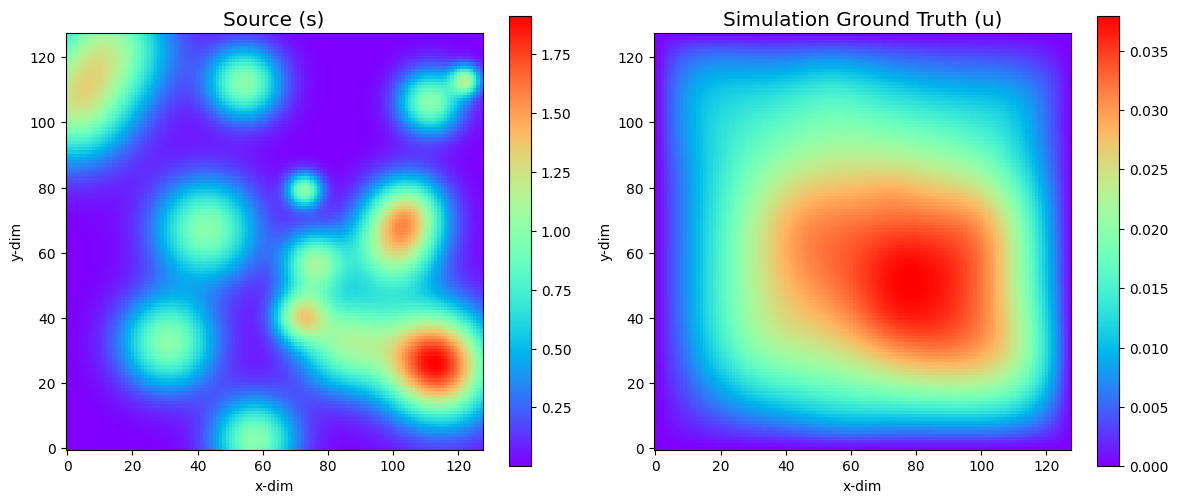

In [4]:
import xarray as xr

ds = xr.open_dataset(FILE_PATH)
print(f"Dataset summary:\n{ds}\n")

sample_idx = 19808

source_sample = ds['source'][sample_idx].values
solution_sample = ds['solution'][sample_idx].values

print(f"Extracted Source Shape: {source_sample.shape}")
print(f"Extracted Solution Shape: {solution_sample.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(source_sample.T, origin='lower', cmap='rainbow')
fig.colorbar(im1, ax=axes[0])
axes[0].set_title('Source (s)', fontsize='x-large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

im2 = axes[1].imshow(solution_sample.T, origin='lower', cmap='rainbow')
fig.colorbar(im2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='x-large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')
plt.tight_layout()
plt.show()

ds.close()

In [5]:
"""
Creating a new dataset with param information
"""
from skimage.feature import peak_local_max
from scipy.optimize import curve_fit

def multi_gaussian_2d(coords, *params):
    x, y = coords
    result = np.zeros_like(x, dtype=float)
    for i in range(0, len(params), 3):
        mu_x, mu_y, sigma = params[i:i+3]
        result += np.exp(-((x - mu_x)**2 + (y - mu_y)**2) / (2 * sigma**2))
    return result.ravel()

if not FILE_MORE_PARAMS_PATH.exists():
    ds = xr.open_dataset(FILE_PATH)
    source_data = ds['source'].values
    ds.close()

    nx, ny = source_data.shape[1], source_data.shape[2]
    x_grid, y_grid = np.meshgrid(np.arange(nx), np.arange(ny), indexing='ij')

    results = []
    print(f"Extracting for {len(source_data)} samples...")

    sigma_min_px = 0.025 * nx
    sigma_max_px = 0.1 * nx
    sigma_guess_px = 0.0625 * nx

    for idx, sample in enumerate(tqdm(source_data, desc="Extracting Parameters")):
        row_data = {'sample_idx': idx}
        
        peak_indices = peak_local_max(sample, min_distance=5, threshold_rel=0.1, exclude_border=False)
        N = len(peak_indices)
        row_data['N'] = N
        
        initial_guess = []
        lower_bounds = []
        upper_bounds = []

        for px, py in peak_indices:
            initial_guess.extend([px, py, sigma_guess_px])
            lower_bounds.extend([0, 0, sigma_min_px])
            upper_bounds.extend([nx, ny, sigma_max_px])
            
        popt, _ = curve_fit(
            multi_gaussian_2d, 
            (x_grid, y_grid), 
            sample.ravel(), 
            p0=initial_guess,
            bounds=(lower_bounds, upper_bounds)
        )
        
        # raw pixel parameters for this specific sample, need to normalize later
        for i in range(N):
            fit_mu_x, fit_mu_y, fit_sigma_pixels = popt[i*3 : (i+1)*3]
            
            row_data[f'mu_x_{i}'] = fit_mu_x 
            row_data[f'mu_y_{i}'] = fit_mu_y 
            row_data[f'sigma_{i}'] = fit_sigma_pixels 
                
        results.append(row_data)

    df = pd.DataFrame(results)
    df.to_csv(FILE_MORE_PARAMS_PATH, index=False)
    print(f"\nExtraction complete! Data saved to: {FILE_MORE_PARAMS_PATH}")

In [6]:
df = pd.read_csv(FILE_MORE_PARAMS_PATH)
df = df.fillna(0.0)

mu_x_cols = [col for col in df.columns if col.startswith('mu_x')]
N_max = len(mu_x_cols)
print(f"Network will accept a maximum of {N_max} peaks.")

Network will accept a maximum of 18 peaks.


In [7]:
df.head()

,sample_idx,N,mu_x_0,mu_y_0,sigma_0,mu_x_1,mu_y_1,sigma_1,mu_x_2,mu_y_2,...,sigma_14,mu_x_15,mu_y_15,sigma_15,mu_x_16,mu_y_16,sigma_16,mu_x_17,mu_y_17,sigma_17
0,0,2,103.691956,2.107274,8.988455,5.224124,34.397806,11.915725,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2,3.112036,107.844472,12.309281,119.221734,69.312186,10.164830,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,1,51.580360,6.632716,5.085781,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,1,38.083757,73.992379,9.613451,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,1,46.551546,120.119422,4.196299,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
class PoissonGaussDataset(Dataset):
    def __init__(self, source_data, solution_data, parameters):
        # Reshape (N, 128, 128) to (N, 16384, 1)
        self.s = source_data.reshape(source_data.shape[0], -1, 1)
        self.u = solution_data.reshape(solution_data.shape[0], -1, 1)
        self.p = parameters

    def __len__(self):
        return len(self.p)

    def __getitem__(self, idx):
        return self.s[idx], self.u[idx], self.p[idx]

param_cols = [col for col in df.columns if col != 'sample_idx']
all_params = np.array(df[param_cols].values) / 128.0  # Normalize to [0, 1], shape: (20000, 3 * N_max), N_max = 18

ds = xr.open_dataset(FILE_PATH)
all_source = ds['source'].values
all_solution = ds['solution'].values
ds.close()

n_train = 19640
n_val = 120
n_test = 240

train_dataset = PoissonGaussDataset(
    source_data=all_source[:n_train], 
    solution_data=all_solution[:n_train], 
    parameters=all_params[:n_train]
)

val_dataset = PoissonGaussDataset(
    source_data=all_source[n_train : n_train + n_val], 
    solution_data=all_solution[n_train : n_train + n_val], 
    parameters=all_params[n_train : n_train + n_val]
)

test_dataset = PoissonGaussDataset(
    source_data=all_source[-n_test:], 
    solution_data=all_solution[-n_test:], 
    parameters=all_params[-n_test:]
)

# We use batch_size=8 here meaning 8 complete samples (and their 16384 points) per batch.
batch_size_samples = 32 
train_dataloader = jd.DataLoader(
    train_dataset, 
    backend='pytorch', 
    batch_size=batch_size_samples, 
    shuffle=True, 
    drop_last=True,
    num_workers=0
)

val_dataloader = jd.DataLoader(
    val_dataset, 
    backend='pytorch', 
    batch_size=batch_size_samples, 
    shuffle=False, 
    num_workers=0 
)

test_dataloader = jd.DataLoader(
    test_dataset, 
    backend='pytorch', 
    batch_size=batch_size_samples, 
    shuffle=False, 
    num_workers=0 
)

print(f"DataLoaders ready!")

DataLoaders ready!


In [9]:
nx, ny = source_sample.shape # 128, 128

# normalize
x_coords = np.linspace(0.0, 1.0, nx, dtype=np.float64)
y_coords = np.linspace(0.0, 1.0, ny, dtype=np.float64)

X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

s = jnp.array(source_sample.reshape(-1, 1), dtype=jnp.float64)
u_sim = jnp.array(solution_sample.reshape(-1, 1), dtype=jnp.float64)

# Dirichlet Boundary Condition
x_l, x_u = 0.0, 1.0
y_l, y_u = 0.0, 1.0

bc_left = (x == x_l).flatten() # Array([ True,  True,  True, ..., False, False, False], dtype=bool)
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top # an array of True if on boundary, False if not on boundary.

# Extract only boundary coordinates
x_bc = x[bc_all]
y_bc = y[bc_all]

u_bc = jnp.zeros_like(x_bc) # Dirichlet u=0


E0622 21:06:20.829936  360057 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0622 21:06:20.840503  359563 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [10]:
# Setup the RFF Matrix
sigma = 0.5 

num_params = all_params.shape[1] 
rff_key = jax.random.PRNGKey(99)
B_matrix = jax.random.normal(rff_key, (2 + num_params, M)) * sigma # M is num_frequencies

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in, p_in):    
        self.param('raw_lambda', nn.initializers.constant(-3.0), (1,)) # gives 1e-5 initialization
        
        v = jnp.concatenate([x_in, y_in, p_in])

        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
        h_rff = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])
        all_features = [h_rff]

        h = h_rff
        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h) 
            all_features.append(h)
            
        # Combine RFF and MLP layers
        # Shape becomes: 512 (RFF) + 128 + 128 + 128 + 128 = 1024 nodes
        combined_h = jnp.concatenate(all_features)
            
        return combined_h
    
model = FeatureExtractor(
    hidden_layers=hidden_layers, 
    B_matrix=B_matrix 
)

# Dummy initialization to get the shapes right
key = jax.random.PRNGKey(0)
dummy_x = jnp.array([0.0])
dummy_y = jnp.array([0.0])
dummy_p = all_params[0] 
params = model.init(key, dummy_x, dummy_y, dummy_p)

def get_f(params, x_val, y_val, p_val):
    return model.apply(params, x_val, y_val, p_val)

def get_f_dir(params, x_val, y_val, p_val):
    f = get_f(params, x_val, y_val, p_val)
    
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val, p_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val, p_val)
    
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2, -3))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2, -3))

    return f_xx, f_yy

def get_f_chunk(params, x_val, y_val, p_val, start_idx, chunk_size):
    f = model.apply(params, x_val, y_val, p_val)
    return lax.dynamic_slice(f, (start_idx,), (chunk_size,))

def get_f_dir_chunk(params, x_val, y_val, p_val, start_idx, chunk_size):
    f_xx_chunk = jacfwd(jacfwd(get_f_chunk, argnums=1), argnums=1)(params, x_val, y_val, p_val, start_idx, chunk_size)
    f_yy_chunk = jacfwd(jacfwd(get_f_chunk, argnums=2), argnums=2)(params, x_val, y_val, p_val, start_idx, chunk_size)
    
    f_xx_chunk = jnp.squeeze(f_xx_chunk, axis=(-1, -2))
    f_yy_chunk = jnp.squeeze(f_yy_chunk, axis=(-1, -2))
    
    return f_xx_chunk, f_yy_chunk

def get_u(params, x_val, y_val, p_val, w_single):
    # f shape: (m,)
    f = model.apply(params, x_val, y_val, p_val)
    # Return scalar: dot product of f and w
    return jnp.dot(f, w_single) 

def get_u_dir(params, x_val, y_val, p_val, w_single):
    u_xx = jacfwd(jacfwd(get_u, argnums=1), argnums=1)(params, x_val, y_val, p_val, w_single)
    u_yy = jacfwd(jacfwd(get_u, argnums=2), argnums=2)(params, x_val, y_val, p_val, w_single)
    
    u_xx = jnp.squeeze(u_xx, axis=(-1, -2))
    u_yy = jnp.squeeze(u_yy, axis=(-1, -2))
    
    return u_xx, u_yy

f_spatial_vmap = vmap(get_f, in_axes=(None, 0, 0, None))
f_dir_spatial_vmap = vmap(get_f_dir, in_axes=(None, 0, 0, None))
f_chunk_spatial_vmap = vmap(get_f_chunk, in_axes=(None, 0, 0, None, None, None))
f_dir_chunk_spatial_vmap = vmap(get_f_dir_chunk, in_axes=(None, 0, 0, None, None, None))
u_dir_spatial_vmap = vmap(get_u_dir, in_axes=(None, 0, 0, None, None))

In [11]:
optimizer = optax.adamw(learning_rate=1e-4, weight_decay=1e-4)

# freeze final linear layer weights
def compute_loss_single(params, w_single, x_batch, y_batch, s_single, x_bc, y_bc, u_bc, p_single):
    u_xx, u_yy = u_dir_spatial_vmap(params, x_batch, y_batch, p_single, w_single)
    laplacian_u = u_xx + u_yy
    
    pde_residual = laplacian_u + s_single
    loss_pde = jnp.mean(pde_residual ** 2)
    
    # Boundary Condition Loss (Dirichlet u = 0) 
    f_bc_vals = f_spatial_vmap(params, x_bc, y_bc, p_single)
    u_bc_pred = jnp.dot(f_bc_vals, w_single)
    loss_bc = jnp.mean((u_bc_pred - u_bc) ** 2) * 1000.0

    """
    If we want to train tik_reg on u_sim for a small dataset. Need to remove u_sim losses after finding ideal value

    # f_interior = f_spatial_vmap(params, x_batch, y_batch, p_single)
    # u_pred_interior = jnp.dot(f_interior, w_single)
    # loss_data = jnp.mean((u_pred_interior - u_single) ** 2)
    """
    
    return loss_pde + loss_bc

# VMAP the loss over the batch of sources, parameters and weights
batched_compute_loss = jax.vmap(
    compute_loss_single, 
    in_axes=(None, 0, None, None, 0, None, None, None, 0)
)

In [12]:
def kaczmarz_inner_update(params, w_k, x_pde, y_pde, s_pde, x_bc, y_bc, u_bc, p_single, total_features, chunk_size, alpha, tik_reg):
    """
    Calculates w_{k+1} for a single sample by chunking across the feature dimension (m) using lax.scan.
    """
    b_pde = -s_pde
    b_bc = u_bc * jnp.sqrt(1000.0)
    b_block = jnp.vstack([b_pde, b_bc])
    
    N_rows = b_block.shape[0]
    
    # Pre-calculate how many chunks we have and their starting indices
    num_chunks = total_features // chunk_size
    chunk_indices = jnp.arange(num_chunks) * chunk_size
    
    def build_gram_step(carry, start_idx):
        """
        Accumulate Aw and G
        """
        Aw_acc, G_acc = carry
        end_idx = start_idx + chunk_size
        
        # Generate feature chunk A_i
        f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, p_single, start_idx, chunk_size)
        A_pde_chunk = f_xx + f_yy
        A_bc_chunk = f_chunk_spatial_vmap(params, x_bc, y_bc, p_single, start_idx, chunk_size) * jnp.sqrt(1000.0)
        A_i = jnp.vstack([A_pde_chunk, A_bc_chunk])
        
        # Dynamically slice w_k for this chunk
        w_i = jax.lax.dynamic_slice(w_k, (start_idx, 0), (chunk_size, 1))
        
        Aw_acc += A_i @ w_i
        G_acc += A_i @ A_i.T
        
        return (Aw_acc, G_acc), None
        
    init_carry = (jnp.zeros((N_rows, 1)), jnp.zeros((N_rows, N_rows)))
    (Aw, G), _ = jax.lax.scan(build_gram_step, init_carry, chunk_indices)
    
    # Solve for z using the accumulated Gram matrix
    I = jnp.eye(N_rows)
    z = jnp.linalg.solve(G + tik_reg * I, Aw - b_block)
    
    def update_w_step(carry, start_idx):
        """
        Update weights chunk by chunk
        """
        end_idx = start_idx + chunk_size
        
        f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, p_single, start_idx, chunk_size)
        A_pde_chunk = f_xx + f_yy
        A_bc_chunk = f_chunk_spatial_vmap(params, x_bc, y_bc, p_single, start_idx, chunk_size) * jnp.sqrt(1000.0)
        A_i = jnp.vstack([A_pde_chunk, A_bc_chunk])
        
        w_i = jax.lax.dynamic_slice(w_k, (start_idx, 0), (chunk_size, 1))
        w_i_new = w_i - alpha * (A_i.T @ z)
        
        return carry, w_i_new
        
    _, w_new_chunks = jax.lax.scan(update_w_step, None, chunk_indices)
    
    # w_new_chunks comes out with shape (num_chunks, chunk_size, 1)
    # Flatten it back to (total_features, 1)
    w_new = w_new_chunks.reshape((total_features, 1))
    
    return w_new

In [13]:
@jax.jit(static_argnames=['total_features', 'chunk_size', 'spatial_chunk_size', 'num_sweeps'])
def solve_single_sample(params, x_pde_full, y_pde_full, s_pde_full, x_bc, y_bc, u_bc, p_single, total_features, chunk_size, spatial_chunk_size, alpha, tik_reg, num_sweeps):
    """
    Runs N sweeps of the Kaczmarz update for a SINGLE sample.
    Includes the Double Chunking spatial loop (Outer Loop).
    """
    w_init = jnp.zeros((total_features, 1))
    
    # Calculate how many spatial chunks we have (e.g., 10000 / 1000 = 10)
    total_spatial_points = x_pde_full.shape[0]
    num_spatial_chunks = total_spatial_points // spatial_chunk_size
    spatial_indices = jnp.arange(num_spatial_chunks) * spatial_chunk_size

    def sweep_step(w_carry_sweep, _):
        
        # --- Outer Loop from wk6.md ---
        def spatial_step(w_carry_spatial, start_idx):
            # Slice the 1,000 coordinates for this specific chunk
            x_pde_chunk = jax.lax.dynamic_slice(x_pde_full, (start_idx, 0), (spatial_chunk_size, 1))
            y_pde_chunk = jax.lax.dynamic_slice(y_pde_full, (start_idx, 0), (spatial_chunk_size, 1))
            s_pde_chunk = jax.lax.dynamic_slice(s_pde_full, (start_idx, 0), (spatial_chunk_size, 1))
            
            # Run the inner loop on these 1,000 points (chunk features)
            w_next = kaczmarz_inner_update(
                params, w_carry_spatial, x_pde_chunk, y_pde_chunk, s_pde_chunk, 
                x_bc, y_bc, u_bc, p_single, 
                total_features, chunk_size, alpha, tik_reg
            )
            return w_next, None

        # Scan across the 10 spatial chunks, carrying the updated weights forward
        w_sweep_final, _ = jax.lax.scan(spatial_step, w_carry_sweep, spatial_indices)
        
        return w_sweep_final, None

    # Scan across the number of sweeps
    w_final, _ = jax.lax.scan(sweep_step, w_init, jnp.arange(num_sweeps))
    
    return w_final

batched_solve = jax.vmap(
    solve_single_sample, 
    in_axes=(None, None, None, 0, None, None, None, 0, None, None, None, None, None, None)
)

@jax.jit(static_argnames=['total_features', 'chunk_size', 'spatial_chunk_size', 'num_sweeps'])
def update_kaczmarz_batch(params, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, p_batch, total_features, chunk_size, spatial_chunk_size, alpha, tik_reg, num_sweeps):
    
    w_batch = batched_solve(
        params, x_batch, y_batch, s_batch, 
        x_bc, y_bc, u_bc, p_batch, 
        total_features, chunk_size, spatial_chunk_size, alpha, tik_reg, num_sweeps
    )
    
    return w_batch

In [14]:
def full_forward_and_loss(params, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, p_batch, total_features, chunk_size, spatial_chunk_size):
    raw_val = params['params']['raw_lambda'][0]
    tik_reg = 10 ** (jnp.tanh(raw_val) * 3 - 2) # bound the possible reg vaLue
    
    w_batch = update_kaczmarz_batch(
        params, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, p_batch, 
        total_features, chunk_size, spatial_chunk_size, kaczmarz_alpha, tik_reg, kaczmarz_sweeps
    )
    
    w_batch = jax.lax.stop_gradient(w_batch)
    
    batched_loss = batched_compute_loss(params, w_batch, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, p_batch)
    
    # Return tik_reg as auxiliary data so we can print it
    return jnp.mean(batched_loss), tik_reg

loss_grad_fn = jax.jit(
    value_and_grad(full_forward_and_loss, argnums=0, has_aux=True), 
    static_argnames=['total_features', 'chunk_size', 'spatial_chunk_size']
)

@jax.jit(static_argnames=['total_features', 'chunk_size', 'spatial_chunk_size'])
def update_network(params, opt_state, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, p_batch, total_features, chunk_size, spatial_chunk_size):
    
    (loss, current_lambda), grads = loss_grad_fn(
        params, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, p_batch, total_features, chunk_size, spatial_chunk_size
    )
    
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, opt_state, loss, current_lambda

In [15]:
# pass full x_grid and y_grid to every sample but slice the p_batch
batched_predict = jax.vmap(f_spatial_vmap, in_axes=(None, None, None, 0))

@jax.jit
def fast_eval_step(params, w_batch, x_grid, y_grid, u_batch, p_batch):
    """Evaluate an entire batch using individual weights per sample"""
    # shape (batch_size, 16384, M)
    f_batch = batched_predict(params, x_grid, y_grid, p_batch)
    
    # Batch matmul: (batch_size, 16384, M) @ (batch_size, M, 1) -> (batch_size, 16384, 1)
    u_pred_batch = jnp.matmul(f_batch, w_batch) 
    
    return jnp.mean((u_pred_batch - u_batch)**2)

def evaluate_dataset(dataloader, params, x_grid, y_grid, eval_batch_size, eval_chunk_size):
    total_mse = 0.0
    total_samples = 0
    
    rng = jax.random.PRNGKey(0)
    total_points = x_grid.shape[0]
    
    val_spatial_idx = jax.random.choice(rng, jnp.arange(total_points), shape=(eval_batch_size,), replace=False)
    
    test_x_chunk = x_grid[val_spatial_idx]
    test_y_chunk = y_grid[val_spatial_idx]
    
    for s_batch, u_batch, p_batch in dataloader:
        s_chunk_val = s_batch[:, val_spatial_idx, :]
        
        raw_val = params['params']['raw_lambda'][0]
        learned_lambda = 10 ** (jnp.tanh(raw_val) * 3 - 2)
        
        w_val_batch = update_kaczmarz_batch(
            params, test_x_chunk, test_y_chunk, s_chunk_val, 
            x_bc, y_bc, u_bc, p_batch, 
            total_features, chunk_size, eval_chunk_size, kaczmarz_alpha, learned_lambda, kaczmarz_sweeps
        )
       
        batch_mse = fast_eval_step(params, w_val_batch, x_grid, y_grid, u_batch, p_batch)
        current_batch_size = p_batch.shape[0]
        
        total_mse += batch_mse.item() * current_batch_size
        total_samples += current_batch_size
            
    return total_mse / total_samples

In [16]:
w = jnp.zeros((total_features, 1))
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

# Interior Sampling
total_points = x.shape[0] # 16384
spatial_batch_size = 1000  # How many to sample total for 1 sample
spatial_chunk_size = 250   # Sketch N from spatial_batch_size

# Boundary Sampling
total_bc_points = x_bc.shape[0]
bc_batch_size = 500

rng, pde_shuffle_key, bc_shuffle_key = jax.random.split(rng, 3)
spatial_indices = jax.random.permutation(pde_shuffle_key, total_points)
bc_indices = jax.random.permutation(bc_shuffle_key, total_bc_points)

ptr = 0    # Pointer for interior points
bc_ptr = 0 # Pointer for boundary points

for epoch in range(epochs):
    epoch_loss = 0.0
    num_batches = 0
    
    for s_batch, u_batch, p_batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):

        # Sample Interior PDE Points
        # If we reach the end of the grid, reshuffle and reset the pointer
        if ptr + spatial_batch_size > total_points:
            rng, shuffle_key = jax.random.split(rng)
            spatial_indices = jax.random.permutation(shuffle_key, total_points)
            ptr = 0
            
        # Get next 1000 points without replacement
        batch_idx = spatial_indices[ptr : ptr + spatial_batch_size]
        ptr += spatial_batch_size
        
        x_chunk = x[batch_idx]
        y_chunk = y[batch_idx]
        s_chunk = s_batch[:, batch_idx, :] # Shape becomes: (8, 1000, 1)
        
        # Sample Boundary Points
        if bc_ptr + bc_batch_size > total_bc_points:
            rng, bc_shuffle_key = jax.random.split(rng)
            bc_indices = jax.random.permutation(bc_shuffle_key, total_bc_points)
            bc_ptr = 0
            
        bc_batch_idx = bc_indices[bc_ptr : bc_ptr + bc_batch_size]
        bc_ptr += bc_batch_size
        
        x_bc_chunk = x_bc[bc_batch_idx]
        y_bc_chunk = y_bc[bc_batch_idx]
        u_bc_chunk = u_bc[bc_batch_idx]
        
        # one update per batch of samples
        params, opt_state, loss, current_lambda = update_network(
            params, opt_state, 
            x_chunk, y_chunk, s_chunk, 
            x_bc_chunk, y_bc_chunk, u_bc_chunk,
            p_batch, total_features, chunk_size, spatial_chunk_size
        )
        
        epoch_loss += loss
        num_batches += 1
            
    avg_train_loss = epoch_loss / num_batches
    val_mse = evaluate_dataset(val_dataloader, params, x, y, spatial_batch_size, spatial_chunk_size)
    
    print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.4e} | Val MSE: {val_mse:.4e} | TikReg: {current_lambda:.2e}")

Epoch 1/1:   0%|          | 0/613 [00:00<?, ?it/s]

Epoch 001 | Train Loss: 1.3783e-03 | Val MSE: 3.7279e-07 | TikReg: 1.03e-05


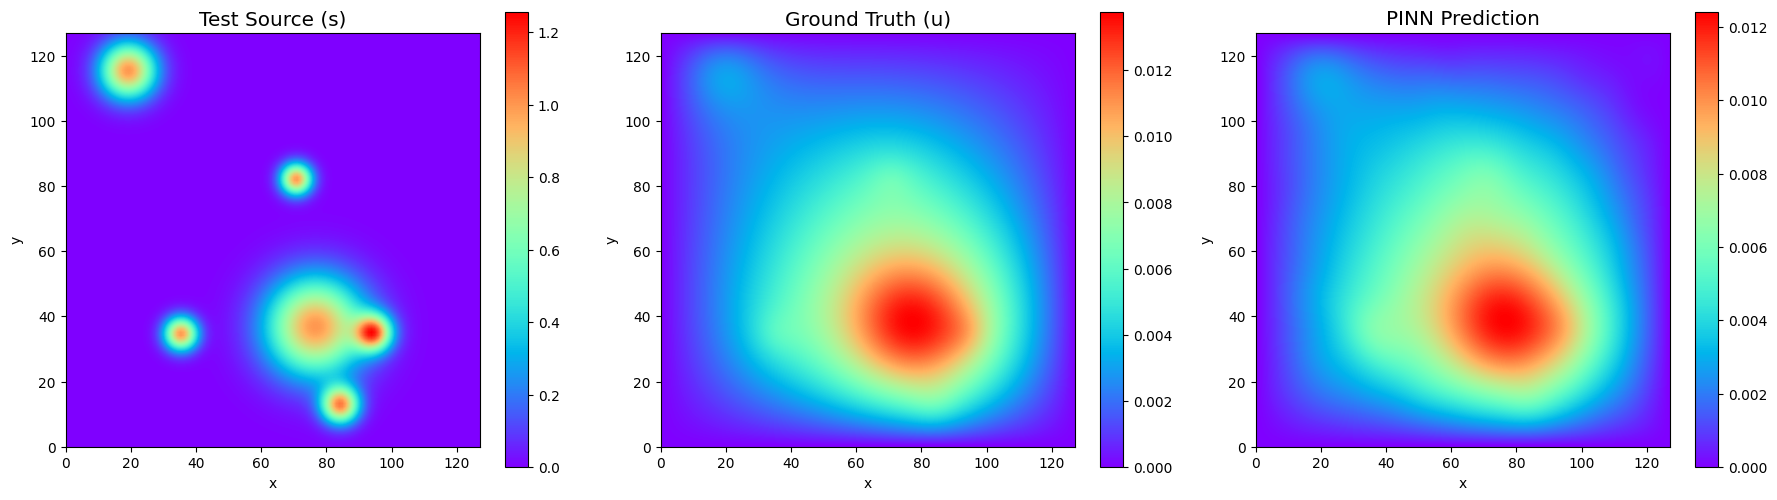

In [20]:
s_sample, u_sim_sample, p_sample = test_dataset[125]

s_batch = s_sample[None, ...]  
p_batch = p_sample[None, ...]  

raw_val = params['params']['raw_lambda'][0]
learned_lambda = 10 ** (jnp.tanh(raw_val) * 3 - 2)

rng_plot = jax.random.PRNGKey(1)

plot_spatial_idx = jax.random.choice(rng_plot, jnp.arange(nx * ny), shape=(spatial_batch_size,), replace=False)

w_plot_batch = update_kaczmarz_batch(
    params, 
    x[plot_spatial_idx], 
    y[plot_spatial_idx], 
    s_batch[:, plot_spatial_idx, :], 
    x_bc, y_bc, u_bc, p_batch, 
    total_features, chunk_size, spatial_chunk_size, kaczmarz_alpha, learned_lambda, kaczmarz_sweeps
)

w_plot = w_plot_batch[0]

f_features = f_spatial_vmap(params, x, y, p_sample)
u_pred = f_features @ w_plot

s_plot = s_sample.reshape(nx, ny).T
u_sim_plot = u_sim_sample.reshape(nx, ny).T 
u_pred_plot = u_pred.reshape(nx, ny).T

ext = [0, nx - 1, 0, ny - 1]
fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(1, 3, 1)
mesh1 = ax1.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=ax1)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Test Source (s)', fontsize='x-large')

ax2 = fig.add_subplot(1, 3, 2)
mesh2 = ax2.imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=ax2)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Ground Truth (u)', fontsize='x-large')

ax3 = fig.add_subplot(1, 3, 3)
mesh3 = ax3.imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=ax3)
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('PINN Prediction', fontsize='x-large')

plt.tight_layout()
plt.show()